In [1]:
import numpy as np
from matplotlib import pyplot as plt

import noctiluca as nl

/home/sgh/gitlibs/chromatin_dynamics/.venv_SD_py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
colors = {
    'blue'    : '#0077BB',
    'cyan'    : '#33BBEE',
    'teal'    : '#009988',
    'orange'  : '#EE7733',
    'red'     : '#CC3311',
    'magenta' : '#EE3377',
    'grey'    : '#BBBBBB',
}

In [3]:
# SPT data
data = nl.io.load.hdf5('/data/sgh/science/2024_minflux/original_data/20250411_SPT_array_CTCF.h5', '/data_twoLocus_maxsep-3um')
# Note: locus 0 is TetO, locus 1 is CTCF
data.makeSelection('NT')
data.addTags('C36')
data.makeSelection('DMSO')
data.addTags('ΔRAD21 (inactive)')
data.makeSelection('IAA')
data.addTags('ΔRAD21 (active)')

for framerate in ['100ms', '2s']:
    data.makeSelection(framerate)
    data.addTags([f'SPT-{framerate}', '2-loc'])

In [4]:
# SRLCI data (from Zenodo)
files = [
    ('C36',               '/data/sgh/science/2024_minflux/raw_data/Fbn2/C36.tagged_set.tsv'),
    ('ΔRAD21 (inactive)', '/data/sgh/science/2024_minflux/raw_data/Fbn2/Rad21_0_hr.tagged_set.tsv'),
    ('ΔRAD21 (active)',   '/data/sgh/science/2024_minflux/raw_data/Fbn2/Rad21_2_hr.tagged_set.tsv'),
    ('ΔRAD21 (active)',   '/data/sgh/science/2024_minflux/raw_data/Fbn2/Rad21_4_hr.tagged_set.tsv'),
]
for tag, file in files:
    data |= nl.io.load.csv(
        file,
        columns=['id', 't', 'x', 'y', 'z', 'x2', 'y2', 'z2'], # xyz is EGFP/ANCHOR3; x2y2z2 is mScarlet/TetO
        tags=[tag, '2-loc', 'SRLCI'],
        delimiter='\t',
        skip_header=1,
    )

In [5]:
# Remove z dimension from SRLCI data (as in production)
data.makeSelection('SRLCI')
data.apply(lambda traj: traj.dims([0, 1]), inplace=True)

In [6]:
# Checks
lens = []
for method in ['SRLCI', 'SPT-100ms', 'SPT-2s']:
    data.makeSelection(method)
    lens.append(len(data))

data.makeSelection()
print(len(data))
print(lens)
print(sum(lens))

for traj in data:
    assert traj.N == 2

3524
[1259, 996, 1269]
3524


In [7]:
# Get single locus and relative coordinate trajectories
loci_by_method = {
    'SRLCI'     : ['ANCHOR3', 'TetO'],
    'SPT-100ms' : ['TetO', 'CTCF'],
    'SPT-2s'    : ['TetO', 'CTCF'],
}

for ct in ['C36', 'ΔRAD21 (inactive)', 'ΔRAD21 (active)']:
    for method, loci in loci_by_method.items():
        data.makeSelection([ct, method, '2-loc'], logic=all)
        
        single = nl.TaggedSet(map(lambda traj: (traj.relative(), [ct, method, 'relative']), data))
        for n, loc in enumerate(loci):
            single |= nl.TaggedSet(map(lambda traj: (nl.Trajectory(traj.data[n]), [ct, method, loc]), data))
            
        data |= single

In [8]:
data.makeSelection(['relative', 'ANCHOR3', 'TetO', 'CTCF'], logic=any)
with nl.Parallelize():
    _ = nl.analysis.MSD(data, show_progress=True)

100%|████████████████████████████████████████████████████████████████████████████████████████| 10572/10572 [00:36<00:00, 292.00it/s]


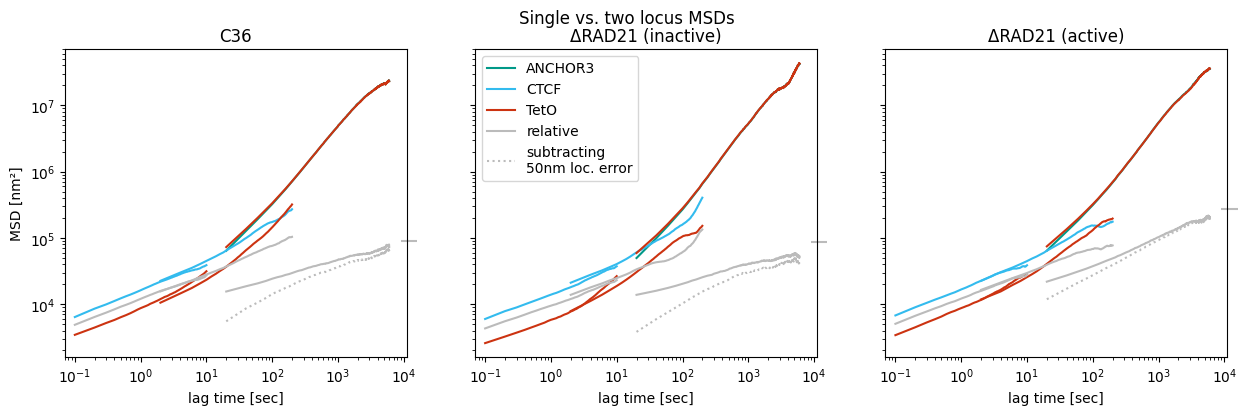

In [21]:
conditions = {
    'SRLCI ANCHOR3 locus' : ['SRLCI',     'ANCHOR3'],
    'SPT-100s Halo-CTCF'  : ['SPT-100ms', 'CTCF'],
    'SPT-2s Halo-CTCF'    : ['SPT-2s',    'CTCF'],
    'SPT-100s TetO locus' : ['SPT-100ms', 'TetO'],
    'SPT-2s TetO locus'   : ['SPT-2s',    'TetO'],
    'SRLCI TetO locus'    : ['SRLCI',     'TetO'],
    'SPT-100s 2p-MSD'     : ['SPT-100ms', 'relative'],
    'SPT-2s 2p-MSD'       : ['SPT-2s',    'relative'],
    'SRLCI 2p-MSD'        : ['SRLCI',     'relative'],
}
plot_colors = {
    'ANCHOR3'  : colors['teal'],
    'CTCF'     : colors['cyan'],
    'TetO'     : colors['red'],
    'relative' : colors['grey'],
}
dts = {
    'SPT-100ms' : 0.1,
    'SPT-2s'    : 2,
    'SRLCI'     : 20,
}
max_dt = {
    'SPT-100ms' : 101,
    'SPT-2s'    : 101,
    'SRLCI'     : 301,
}
excess_loc_err = 50 # nm

fig, axs = plt.subplots(1, 3, figsize=[15, 4], sharex=True, sharey=True)
for ax, ct in zip(axs, ['C36', 'ΔRAD21 (inactive)', 'ΔRAD21 (active)']):
    for label, cond in conditions.items():
        msd_correction_factor = 1/2 if 'relative' in cond else 1
        msd_correction_factor *= 1e6 # convert to nm²

        data.makeSelection([ct, *cond], logic=all)
        if len(data) == 0:
            print(ct, *cond)

        msd = nl.analysis.MSD(data) * msd_correction_factor
        dt    = [val for key, val in dts.items()         if key in cond][0]
        color = [val for key, val in plot_colors.items() if key in cond][0]
        mdt   = [val for key, val in max_dt.items()      if key in cond][0]

        ax.plot(dt*np.arange(1, mdt), msd[1:mdt],
                color=color,
               )
        
        if 'SRLCI' in cond:
            if 'relative' in cond:
                J = np.nanmean(np.concatenate([traj.abs()[:][:, 0] for traj in data])**2)/2*1e6
                ax.hlines(2*J, 9e3, 10**(4.2), color=color, clip_on=False)

                ax.plot(dt*np.arange(1, mdt), msd[1:mdt] - 4*excess_loc_err**2,
                        color=color, linestyle=':'
                       )
#             if 'TetO' in cond or 'relative' in cond:
#                 ax.vlines(dt, msd[1], msd[1] - 4*excess_loc_err**2, color='k', zorder=0)
    
    ax.set_title(ct)

ax = axs[1]
for label, color in plot_colors.items():
    ax.plot(0, 0, color=color, label=label)
ax.plot(0, 0,
        color=plot_colors['relative'],
        linestyle=':',
        label='subtracting\n50nm loc. error'
       )
ax.legend()
ax.set_xlim([0.07, 1.1e4])

ax.set_xscale('log')
ax.set_yscale('log')

for ax in axs:
    ax.set_xlabel('lag time [sec]')
axs[0].set_ylabel('MSD [nm²]')

fig.suptitle('Single vs. two locus MSDs')

plt.savefig('/data/sgh/science/2024_minflux/plots/reviewer_response/single_vs_two_locus.pdf')
plt.savefig('/data/sgh/science/2024_minflux/plots/reviewer_response/single_vs_two_locus.png', dpi=300)
plt.show()